<a href="https://colab.research.google.com/github/PappuBaraf/PappuBaraf/blob/main/time_series_Forcastingpython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0       1
1       3
2       5
3       7
4       9
5      12
6      34
7      67
8      89
9      90
10    123
11    156
12    278
13    290
14    333
15    345
16    466
17    570
Name: values, dtype: int64


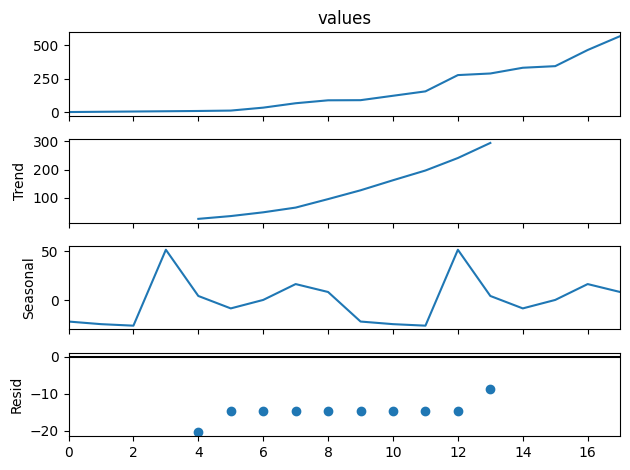

0       NaN
1       1.0
2       3.0
3       5.0
4       7.0
5       9.0
6      12.0
7      34.0
8      67.0
9      89.0
10     90.0
11    123.0
12    156.0
13    278.0
14    290.0
15    333.0
16    345.0
17    466.0
Name: values, dtype: float64
0.8996243833338669
1       2.0
2       2.0
3       2.0
4       2.0
5       3.0
6      22.0
7      33.0
8      22.0
9       1.0
10     33.0
11     33.0
12    122.0
13     12.0
14     43.0
15     12.0
16    121.0
17    104.0
Name: values, dtype: float64
0.9987728540692942
2       0.0
3       0.0
4       0.0
5       1.0
6      19.0
7      11.0
8     -11.0
9     -21.0
10     32.0
11      0.0
12     89.0
13   -110.0
14     31.0
15    -31.0
16    109.0
17    -17.0
Name: values, dtype: float64
0.7854116235000519
3       0.0
4       0.0
5       1.0
6      18.0
7      -8.0
8     -22.0
9     -10.0
10     53.0
11    -32.0
12     89.0
13   -199.0
14    141.0
15    -62.0
16    140.0
17   -126.0
Name: values, dtype: float64
1.6736723288112824e-05
Number of di

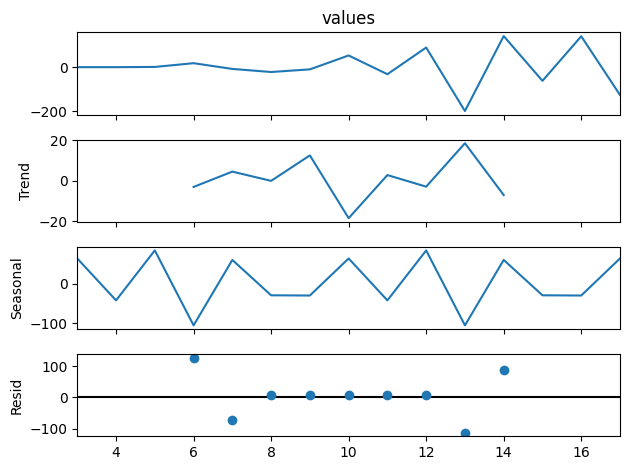

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

data = pd.DataFrame({"values":[1,3,5,7,9,12,34,67,89,90,123,156,278,290,333,345,466,570]})

print(data['values'])

result = seasonal_decompose(data['values'], model='additive', period=9)
result.plot()
plt.show()

print(data['values'].shift(1))

d = adfuller(data['values'])
print(d[1])

c = 0
p = d[1]

if(p < 0.05):
    print("Time Series is stationary")
else:
    while(p > 0.05):
        data = data.diff(1).dropna()
        print(data['values'])
        d = adfuller(data['values'])
        p = d[1]
        c = c + 1
        print(p)

print("Number of differencing performed", c)
print(data['values'])

result = seasonal_decompose(data['values'], model='additive', period=7)
result.plot()
plt.show()

In [12]:
import statsmodels.graphics.tsaplots as smg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

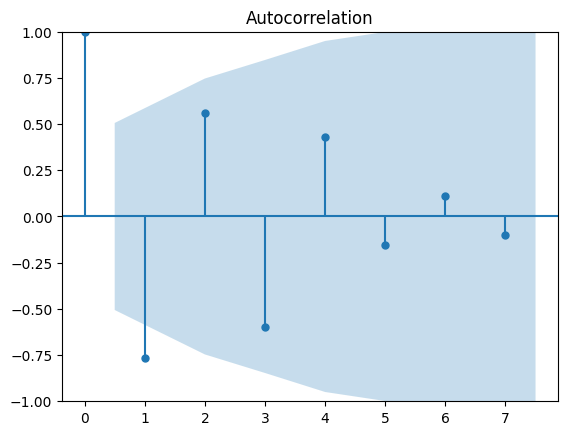

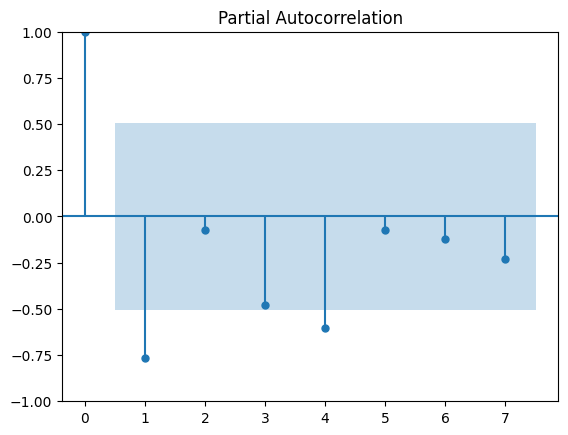

In [13]:
plot_acf(data['values'])
plot_pacf(data['values'])
plt.show()

In [14]:
from statsmodels.tsa.arima_model import ARIMA

In [15]:
from statsmodels.tsa.arima.model import ARIMA

In [17]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data['values'], order=(2,3,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 values   No. Observations:                   15
Model:                 ARIMA(2, 3, 1)   Log Likelihood                 -75.542
Date:                Fri, 27 Feb 2026   AIC                            159.083
Time:                        05:34:47   BIC                            161.023
Sample:                             0   HQIC                           158.365
                                 - 15                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.2773      0.243     -5.262      0.000      -1.753      -0.802
ar.L2         -0.3242      0.267     -1.215      0.224      -0.847       0.199
ma.L1         -0.9997      0.672     -1.487      0.1

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Usin

In [19]:
forecast = model_fit.forecast(steps=10)
print(forecast)

15     67.540766
16   -181.161763
17    -20.904418
18   -246.630849
19   -118.863115
20   -324.468282
21   -225.800888
22   -414.688590
23   -341.872430
24   -517.089469
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


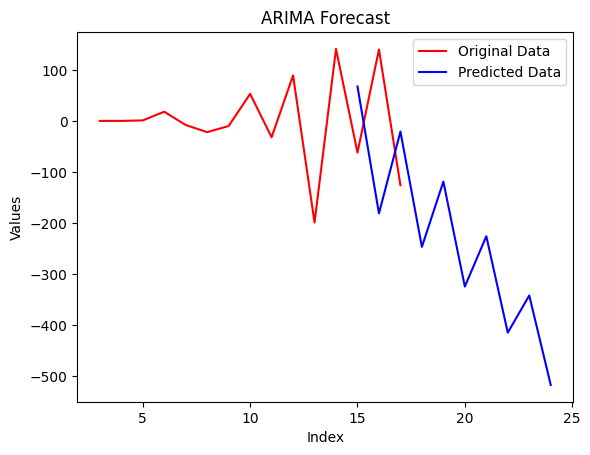

In [20]:
# Forecast next 10 values
predicted = model_fit.forecast(steps=10)

# Plot original data (red)
plt.plot(data['values'], color='red', label='Original Data')

# Plot predicted data (blue)
plt.plot(
    range(len(data['values']), len(data['values']) + 10),
    predicted,
    color='blue',
    label='Predicted Data'
)

plt.xlabel("Index")
plt.ylabel("Values")
plt.title("ARIMA Forecast")
plt.legend()
plt.show()